In [16]:
from astropy.io import fits
import numpy as np
import os


def compute_weight_cut(weight_file, percentile=5.0):
    """
    Compute a representative low-weight cutoff from a DECam weight map.

    Parameters
    ----------
    weight_file : str
        Path to weight FITS file
    percentile : float
        Percentile of non-zero weights

    Returns
    -------
    cutoff : float
        Weight value at given percentile
    """
    data = fits.getdata(weight_file)

    good = data[data > 0]
    cutoff = np.percentile(good, percentile)

    return cutoff


if __name__ == "__main__":

    WEIGHT_FILES = [
        "/Users/aishwarya/Desktop/Lyman_alpha_2/Mosaiced_images/Trim2deg/trim2deg_weight_i.fits",
        "/Users/aishwarya/Desktop/Lyman_alpha_2/Mosaiced_images/Trim2deg/trim2deg_weight_n964.fits",
        "/Users/aishwarya/Desktop/Lyman_alpha_2/Mosaiced_images/Trim2deg/trim2deg_weight_z.fits",
    ]

    PERCENTILE = 20.0   # same definition across all bands

    print("DECam weight cut values (no masking):\n")

    for wf in WEIGHT_FILES:
        cutoff = compute_weight_cut(wf, percentile=PERCENTILE)

        print(f"{os.path.basename(wf)}")
        print(f"  {PERCENTILE:.1f}th percentile weight = {cutoff:.6e}\n")


DECam weight cut values (no masking):

trim2deg_weight_i.fits
  20.0th percentile weight = 8.533185e-04

trim2deg_weight_n964.fits
  20.0th percentile weight = 8.787756e-03

trim2deg_weight_z.fits
  20.0th percentile weight = 1.020950e-03



trim2deg_weight_i.fits
  Science peak (mode) ≈ 8.953540e-04



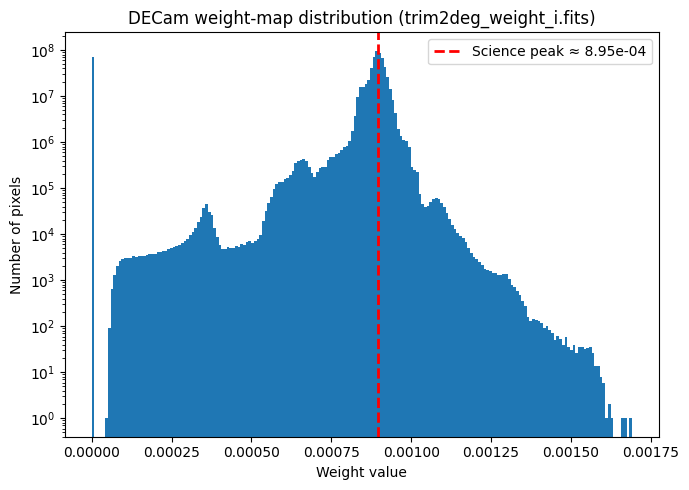

trim2deg_weight_n964.fits
  Science peak (mode) ≈ 9.117992e-03



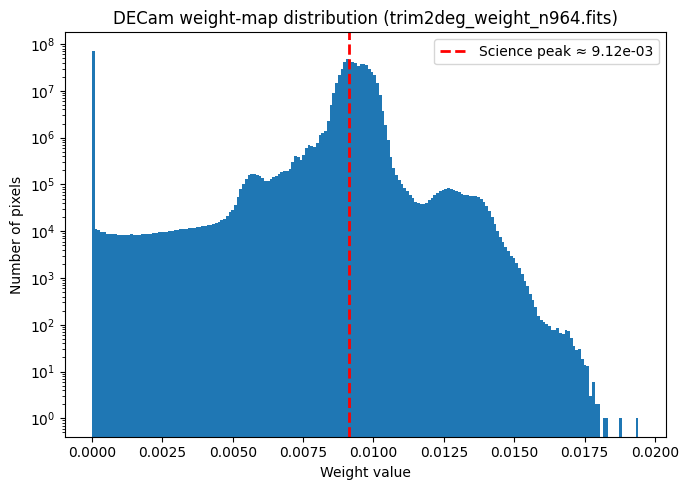

trim2deg_weight_z.fits
  Science peak (mode) ≈ 1.075196e-03



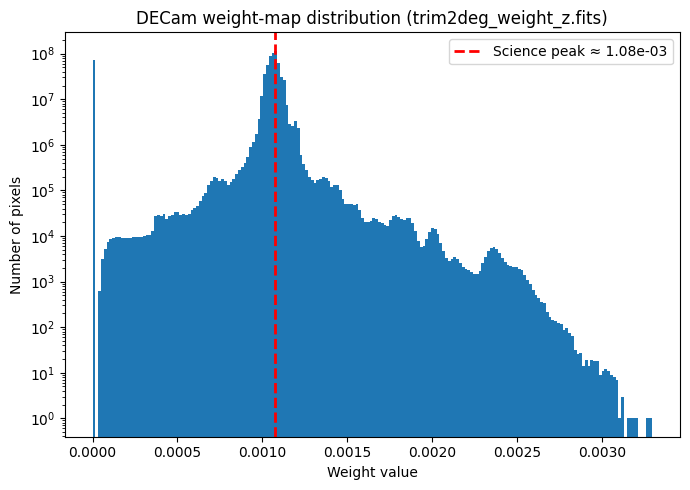

In [10]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import os


WEIGHT_FILES = [
    "/Users/aishwarya/Desktop/Lyman_alpha_2/Mosaiced_images/Trim2deg/trim2deg_weight_i.fits",
    "/Users/aishwarya/Desktop/Lyman_alpha_2/Mosaiced_images/Trim2deg/trim2deg_weight_n964.fits",
    "/Users/aishwarya/Desktop/Lyman_alpha_2/Mosaiced_images/Trim2deg/trim2deg_weight_z.fits",
]


def find_science_peak(good, bins=200):
    """
    Find the main science peak of a DECam weight distribution.

    This explicitly removes the low-weight tail (edges, gaps),
    which otherwise dominates the histogram mode.
    """

    # Remove the lowest-weight tail explicitly
    # (keep only reasonably well-exposed pixels)
    low_cut = 0.3 * np.max(good)
    trimmed = good[good > low_cut]

    # Histogram of trimmed distribution
    counts, bin_edges = np.histogram(trimmed, bins=bins)

    # Mode of the histogram
    peak_bin = np.argmax(counts)
    peak_value = 0.5 * (bin_edges[peak_bin] + bin_edges[peak_bin + 1])

    return peak_value


for wf in WEIGHT_FILES:

    # Load weight map
    w = fits.getdata(wf)

    # Keep only valid pixels
    good = w[w > 0]

    # Find science peak
    peak_value = find_science_peak(good)

    print(f"{os.path.basename(wf)}")
    print(f"  Science peak (mode) ≈ {peak_value:.6e}\n")

    # Plot full distribution
    plt.figure(figsize=(7, 5))
    plt.hist(good, bins=200, log=True)

    # Mark science peak
    plt.axvline(
        peak_value,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Science peak ≈ {peak_value:.2e}"
    )

    plt.xlabel("Weight value")
    plt.ylabel("Number of pixels")
    plt.title(f"DECam weight-map distribution ({os.path.basename(wf)})")
    plt.legend()
    plt.tight_layout()
    plt.show()



=== Deriving weight thresholds ===

I band
  File       : /Users/aishwarya/Desktop/Lyman_alpha_2/Mosaiced_images/Trim2deg/trim2deg_weight_i.fits
  Max weight : 1.692e-03
  20% cutoff : 8.533e-04
  Pixels kept: 71.73%



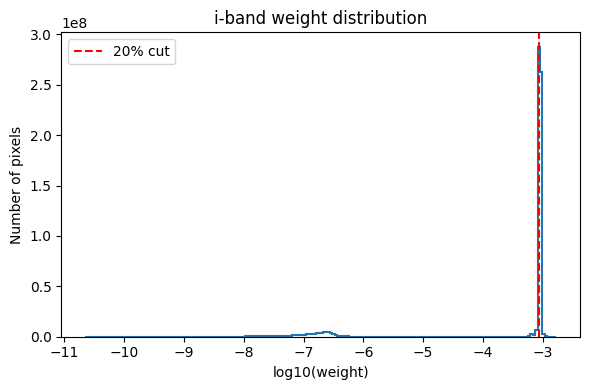

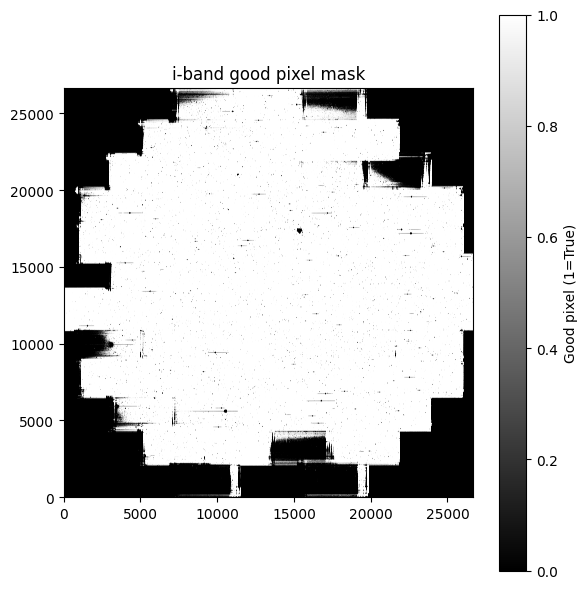

N964 band
  File       : /Users/aishwarya/Desktop/Lyman_alpha_2/Mosaiced_images/Trim2deg/trim2deg_weight_n964.fits
  Max weight : 1.941e-02
  20% cutoff : 8.788e-03
  Pixels kept: 71.67%



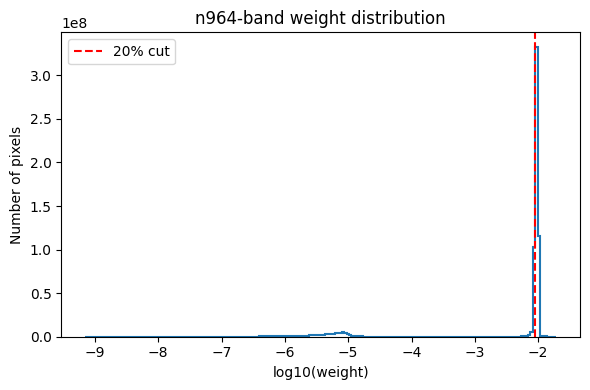

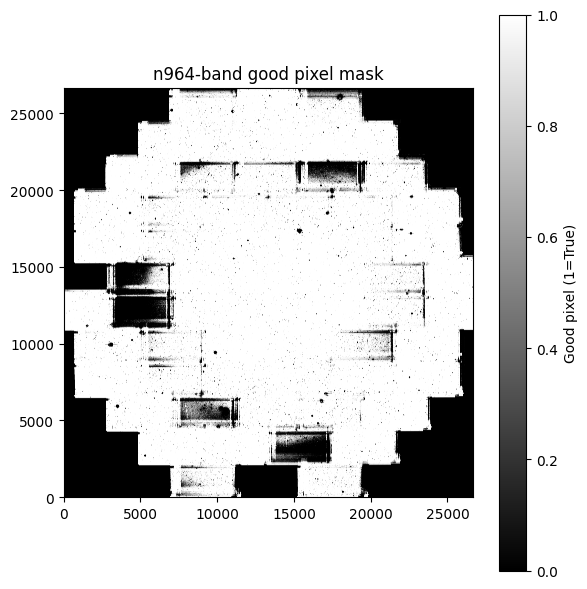

Z band
  File       : /Users/aishwarya/Desktop/Lyman_alpha_2/Mosaiced_images/Trim2deg/trim2deg_weight_z.fits
  Max weight : 3.296e-03
  20% cutoff : 1.021e-03
  Pixels kept: 71.77%



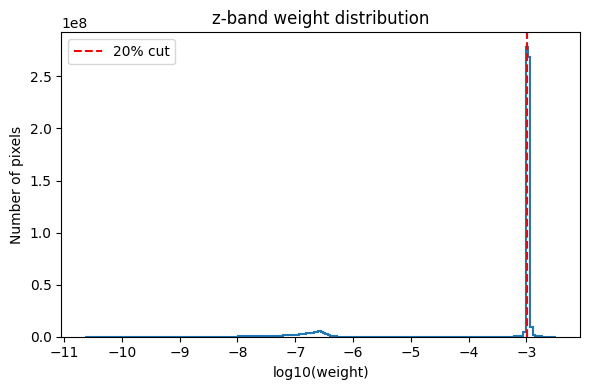

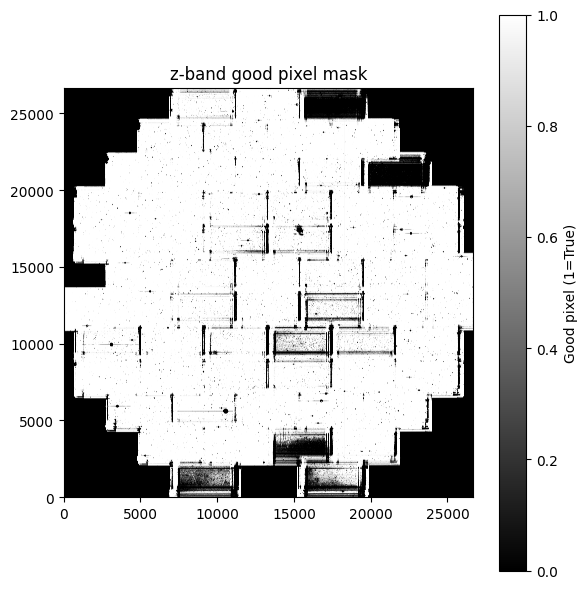

Y band
  File       : /Users/aishwarya/Desktop/Lyman_alpha_2/Y_band/Trim/trim2deg_weight_y.fits
  Max weight : 9.893e-03
  20% cutoff : 3.782e-03
  Pixels kept: 71.82%



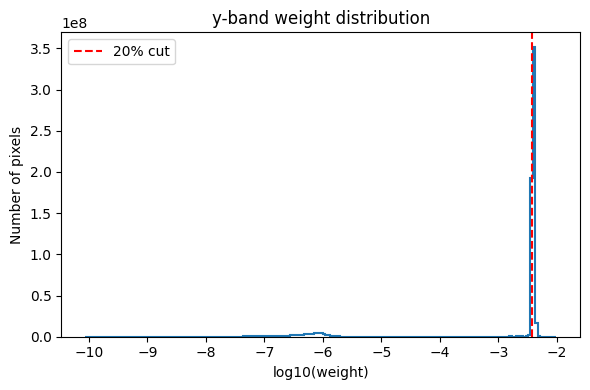

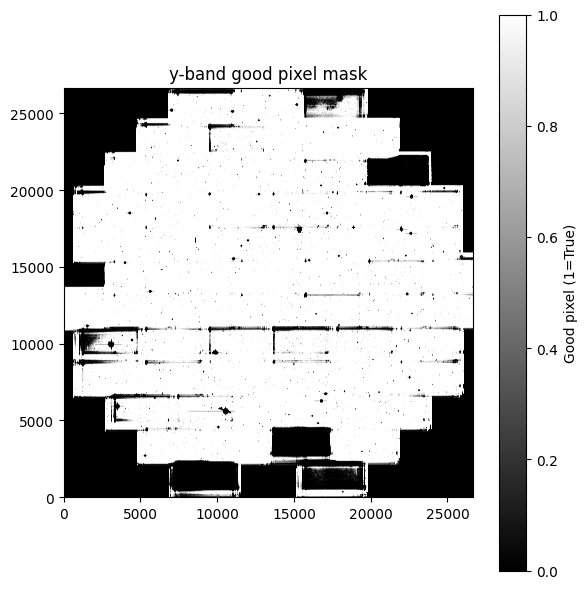

=== Recommended WEIGHTS block ===

WEIGHTS = [
    ('/Users/aishwarya/Desktop/Lyman_alpha_2/Mosaiced_images/Trim2deg/trim2deg_weight_n964.fits', 0.00878776),
    ('/Users/aishwarya/Desktop/Lyman_alpha_2/Mosaiced_images/Trim2deg/trim2deg_weight_i.fits', 0.000853318),
    ('/Users/aishwarya/Desktop/Lyman_alpha_2/Mosaiced_images/Trim2deg/trim2deg_weight_z.fits', 0.00102095),
    ('/Users/aishwarya/Desktop/Lyman_alpha_2/Y_band/Trim/trim2deg_weight_y.fits', 0.0037825),
]



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import os


WEIGHT_FILES = {
    "i": "/Users/aishwarya/Desktop/Lyman_alpha_2/Mosaiced_images/Trim2deg/trim2deg_weight_i.fits",
    "n964": "/Users/aishwarya/Desktop/Lyman_alpha_2/Mosaiced_images/Trim2deg/trim2deg_weight_n964.fits",
    "z": "/Users/aishwarya/Desktop/Lyman_alpha_2/Mosaiced_images/Trim2deg/trim2deg_weight_z.fits",
    "y":"/Users/aishwarya/Desktop/Lyman_alpha_2/Y_band/Trim/trim2deg_weight_y.fits"
}

# Percentile used to define minimum acceptable weight
PERCENTILE_CUT = 20  # 5% is standard



def load_weights(path):
    """Load weight map and return valid positive values."""
    data = fits.getdata(path)
    good = np.isfinite(data) & (data > 0)
    return data, data[good]


def derive_threshold(weights, percentile):
    """Compute percentile-based threshold."""
    return np.percentile(weights, percentile)


def plot_histogram(weights, band, threshold):
    """Plot log-weight histogram with threshold marker."""
    plt.figure(figsize=(6, 4))
    plt.hist(np.log10(weights), bins=200, histtype="step", lw=1.5)
    plt.axvline(np.log10(threshold), color="red", ls="--",
                label=f"{PERCENTILE_CUT}% cut")
    plt.xlabel("log10(weight)")
    plt.ylabel("Number of pixels")
    plt.title(f"{band}-band weight distribution")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_mask(weight_map, threshold, band):
    """Plot good/bad pixel mask."""
    mask = weight_map >= threshold
    plt.figure(figsize=(6, 6))
    plt.imshow(mask, origin="lower", cmap="gray")
    plt.title(f"{band}-band good pixel mask")
    plt.colorbar(label="Good pixel (1=True)")
    plt.tight_layout()
    plt.show()



def main():

    print("\n=== Deriving weight thresholds ===\n")

    thresholds = {}

    for band, path in WEIGHT_FILES.items():

        if not os.path.exists(path):
            raise FileNotFoundError(f"{path} not found")

        weight_map, weights = load_weights(path)

        threshold = derive_threshold(weights, PERCENTILE_CUT)
        thresholds[band] = threshold

        print(f"{band.upper()} band")
        print(f"  File       : {path}")
        print(f"  Max weight : {np.max(weights):.3e}")
        print(f"  {PERCENTILE_CUT}% cutoff : {threshold:.3e}")
        print(f"  Pixels kept: {(weight_map >= threshold).sum() / weight_map.size:.2%}\n")

        # Diagnostic plots
        plot_histogram(weights, band, threshold)
        plot_mask(weight_map, threshold, band)

    print("=== Recommended WEIGHTS block ===\n")
    print("WEIGHTS = [")
    for band in ["n964", "i", "z", "y"]:
        print(f"    ('{WEIGHT_FILES[band]}', {thresholds[band]:.6g}),")
    print("]\n")



if __name__ == "__main__":
    main()
